In [36]:
import pandas as pd
import numpy as np

In [37]:
df= pd.read_csv("./datasets/metrices.csv")

In [38]:
df.head()

,x1,x2,y
0,1,2,7.9
1,2,1,7.1
2,3,4,17.8
3,4,3,17.2
4,5,5,25.3


In [39]:
df.describe()

,x1,x2,y
count,40.000000,40.000000,40.000000
mean,20.500000,11.000000,85.260000
std,11.690452,5.861653,48.492425
min,1.000000,1.000000,7.100000
25%,10.750000,6.000000,45.200000
50%,20.500000,11.000000,84.650000
75%,30.250000,16.000000,124.625000
max,40.000000,21.000000,165.400000


In [40]:
df.corr()

,x1,x2,y
x1,1.000000,0.987843,0.998556
x2,0.987843,1.000000,0.994390
y,0.998556,0.994390,1.000000


In [41]:
df.cov()

,x1,x2,y
x1,136.666667,67.692308,566.079487
x2,67.692308,34.358974,282.651282
y,566.079487,282.651282,2351.515282


### Seeing the pattern of each input column with the Op colm

C:\Users\Yunish\AppData\Local\Temp\ipykernel_13440\2430838987.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


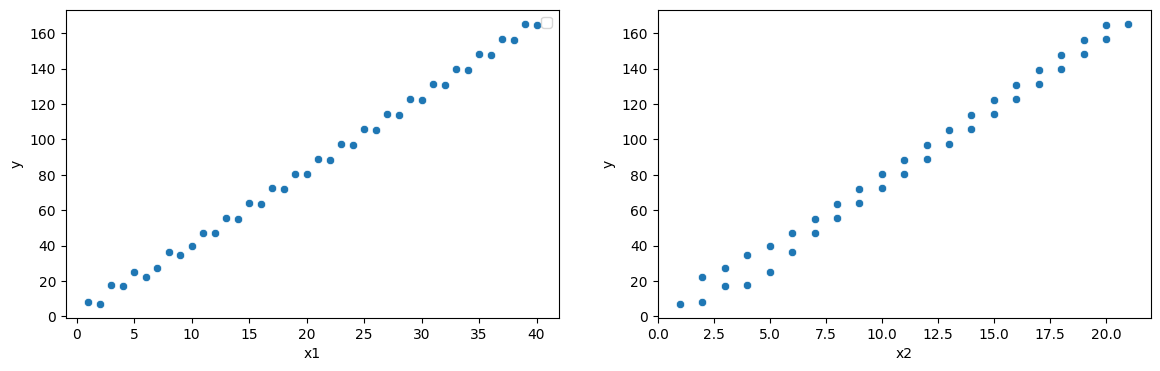

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (14,4))

plt.subplot(1, 2, 1)
sns.scatterplot(x= df['x1'], y= df['y'])
plt.legend()
plt.xlabel('x1')
plt.ylabel('y')



plt.subplot(1, 2, 2)
sns.scatterplot(x= df['x2'], y= df['y'])
plt.xlabel('x2')
plt.ylabel('y')
plt.show()

In [49]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(df.drop(columns= ['y']), df['y'], random_state= 42, test_size= 0.2)

In [50]:
from sklearn.linear_model import LinearRegression

model= LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


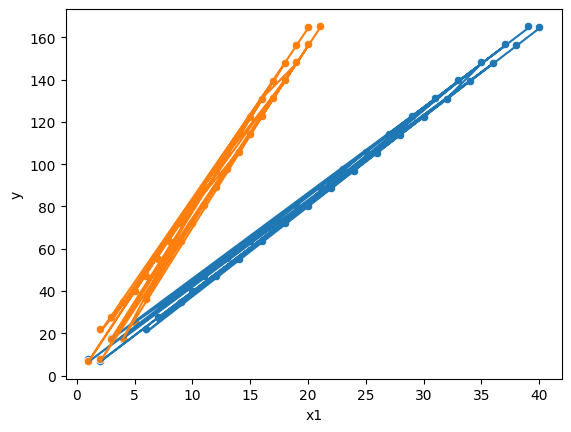

In [53]:
#to see the fit line of the model

plt.plot(x_train, model.predict(x_train))
sns.scatterplot(x= df['x1'], y= df['y'])
sns.scatterplot(x= df['x2'], y= df['y'])


plt.show()   #I have 2 ip colum so it kinda looked messy. If I have only one ip col then it will look clear

In [56]:
model.intercept_  #value of b


np.float64(-1.7721843842872005)

In [61]:
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score


print("MAE", mean_absolute_error(y_true= y_test, y_pred=model.predict(x_test)))
print("MSE", mean_squared_error(y_true= y_test, y_pred=model.predict(x_test)))
print("R2", r2_score(y_true= y_test, y_pred=model.predict(x_test)))
print("RMSE", np.sqrt(mean_squared_error(y_true= y_test, y_pred=model.predict(x_test))))


MAE 0.5914994057270957
MSE 0.46537325689192655
R2 0.9996859681247482
RMSE 0.6821827151811504


In [60]:
df.shape

(40, 3)

In [64]:
# For Adjusted R2 score
adjr2= 1-((1-0.9996859681247482)*(40-1)/(40-2-1))
print("Adjuested R2 Score", adjr2)

Adjuested R2 Score 0.9996689934287887
